# Data Pipeline 
## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Settings
Checking if the Train, Test, Val split exists.

In [2]:
SPLIT_DIR  = Path("../data/PlantVillage_split")
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

# Verify split folders exist
for split in ["train", "val", "test"]:
    path = SPLIT_DIR / split
    assert path.exists(), f"Missing folder: {path}"

print("   All split folders found")
print(f"   Image size : {IMG_SIZE}")
print(f"   Batch size : {BATCH_SIZE}")

   All split folders found
   Image size : (224, 224)
   Batch size : 32


## Training generator with augmentation
Augmentation helps to create slightly modified copies of images so the model can learn to handle real-world variation (i.e. different angles, lighting, etc.).

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalise pixels from 0-255 to 0-1
    rotation_range=20,       # randomly rotate up to 20 degrees
    width_shift_range=0.2,   # randomly shift image left/right
    height_shift_range=0.2,  # randomly shift image up/down
    horizontal_flip=True,    # randomly mirror image left-right
    zoom_range=0.2,          # randomly zoom in up to 20%
    shear_range=0.1,         # slight shearing transformation
    fill_mode="nearest"      # fill any empty pixels after transformation
)

train_generator = train_datagen.flow_from_directory(
    SPLIT_DIR / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

print(f"  Training generator ready")
print(f"   Samples : {train_generator.samples}")
print(f"   Classes : {train_generator.num_classes}")
print(f"   Batches : {len(train_generator)}")

Found 9430 images belonging to 15 classes.
  Training generator ready
   Samples : 9430
   Classes : 15
   Batches : 295


## Validation generateor without augmentation
Validation images must not be augmented beacuse we want to evaluate on clean images to get a true measure of performance.

In [4]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    SPLIT_DIR / "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,   # keep order for evaluation later
    seed=SEED
)

print(f"  Validation generator ready")
print(f"   Samples : {val_generator.samples}")
print(f"   Classes : {val_generator.num_classes}")
print(f"   Batches : {len(val_generator)}")

Found 2018 images belonging to 15 classes.
  Validation generator ready
   Samples : 2018
   Classes : 15
   Batches : 64


## Test generator without Augmentation
Test set is prepared now but only be used in evaluation. Use this evaluation only when model is fully trained.

In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    SPLIT_DIR / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)

print(f"  Test generator ready")
print(f"   Samples : {test_generator.samples}")
print(f"   Classes : {test_generator.num_classes}")
print(f"   Batches : {len(test_generator)}")

Found 2026 images belonging to 15 classes.
  Test generator ready
   Samples : 2026
   Classes : 15
   Batches : 64


## Verification of class 
Verifying the classes so that all splits have same classes

In [6]:
train_classes = set(train_generator.class_indices.keys())
val_classes   = set(val_generator.class_indices.keys())
test_classes  = set(test_generator.class_indices.keys())

assert train_classes == val_classes == test_classes, \
    "Class mismatch between splits!"

print(" All splits have identical classes")
print(f"\nFirst 5 classes: {list(train_generator.class_indices.keys())[:5]}")
print(f"Last  5 classes: {list(train_generator.class_indices.keys())[-5:]}")

 All splits have identical classes

First 5 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Last  5 classes: ['Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


## Visualize Augmentation
This is to show how augmentation works and how model sees during training. This visualizes only one image.

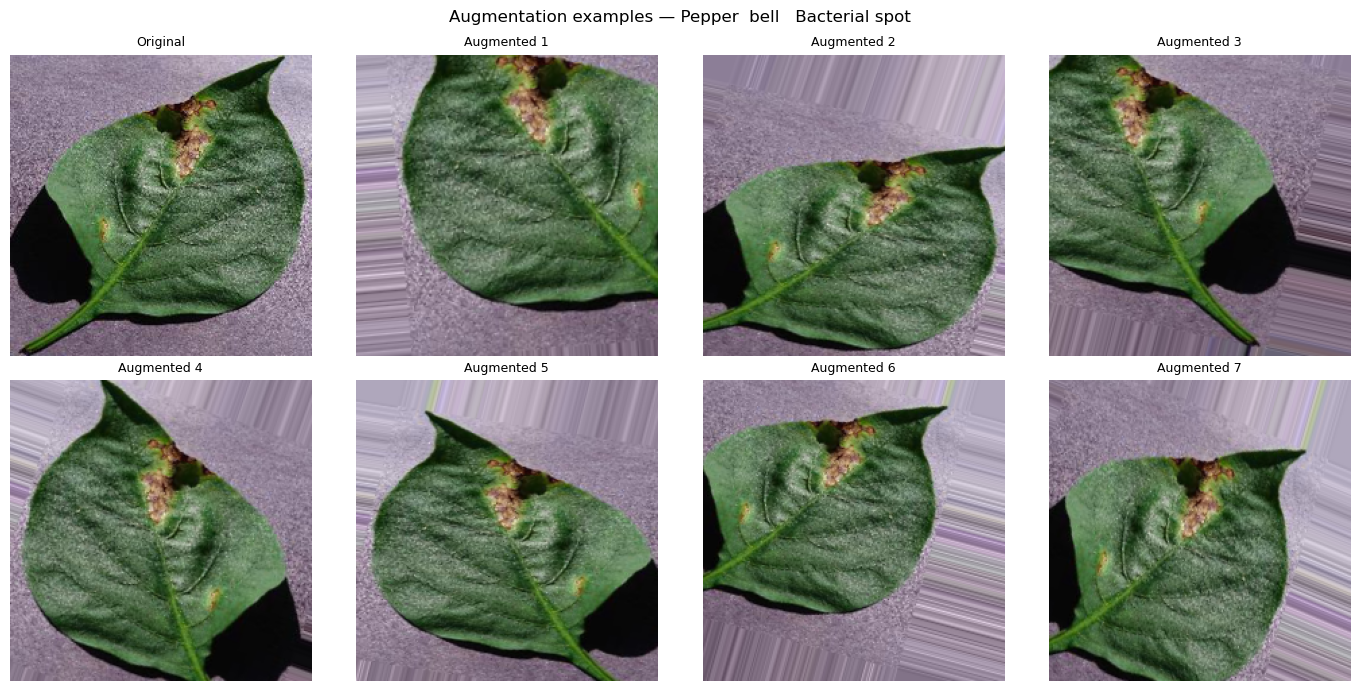

Saved → results/augmentation_examples.png


In [7]:
sample_class = list(train_generator.class_indices.keys())[0]
sample_dir   = SPLIT_DIR / "train" / sample_class
sample_image = list(sample_dir.iterdir())[0]

# Load image WITHOUT normalising — let the datagen handle that
img = Image.open(sample_image).convert("RGB").resize(IMG_SIZE)
img_array = np.array(img)  # keep as 0-255, do NOT divide by 255 here
img_batch = img_array.reshape((1,) + img_array.shape)

# Generate 8 augmented versions
aug_gen = train_datagen.flow(img_batch, batch_size=1, seed=SEED)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Display original (divide by 255 only for display)
axes[0, 0].imshow(img_array.astype("uint8"))
axes[0, 0].set_title("Original", fontsize=9)
axes[0, 0].axis("off")

for i, ax in enumerate(axes.flatten()[1:]):
    aug_img = next(aug_gen)[0]  # this comes out normalised 0-1, fine for imshow
    ax.imshow(aug_img)
    ax.set_title(f"Augmented {i+1}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Augmentation examples — {sample_class.replace('_', ' ')}", fontsize=12)
plt.tight_layout()
plt.savefig("../results/augmentation_examples.png", dpi=150)
plt.show()
print("Saved → results/augmentation_examples.png")

## Check Shapes
This loads image of one batch and checks if shapes are correct 

In [8]:
images, labels = next(train_generator)

print(f"Image batch shape : {images.shape}")   # should be (32, 224, 224, 3)
print(f"Label batch shape : {labels.shape}")   # should be (32, num_classes)
print(f"Pixel value range : {images.min():.2f} to {images.max():.2f}")  # should be 0.0 to 1.0
print(f"Label example     : {labels[0]}")      # one-hot encoded vector

Image batch shape : (32, 224, 224, 3)
Label batch shape : (32, 15)
Pixel value range : 0.00 to 1.00
Label example     : [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Load and verify class weights 
This loads the class weights that were calculated earlier and verifies that they were saved correctly. Which will later be used during model training to handle class imbalance.

In [9]:
class_weights = np.load("../models/class_weights.npy")
class_names   = np.load("../models/class_names.npy", allow_pickle=True)

class_weight_dict = dict(enumerate(class_weights))

print(f"Class weights loaded for {len(class_weights)} classes")
print()
print("5 highest weighted classes (rarest):")
top5 = np.argsort(class_weights)[::-1][:5]
for i in top5:
    print(f"  {class_names[i]:45s}  weight: {class_weights[i]:.3f}")

print()
print("5 lowest weighted classes (most common):")
bot5 = np.argsort(class_weights)[:5]
for i in bot5:
    print(f"  {class_names[i]:45s}  weight: {class_weights[i]:.3f}")

Class weights loaded for 15 classes

5 highest weighted classes (rarest):
  Potato___healthy                               weight: 5.931
  Tomato__Tomato_mosaic_virus                    weight: 2.409
  Tomato_Leaf_Mold                               weight: 0.944
  Pepper__bell___Bacterial_spot                  weight: 0.902
  Tomato__Target_Spot                            weight: 0.898

5 lowest weighted classes (most common):
  Pepper__bell___healthy                         weight: 0.898
  Potato___Early_blight                          weight: 0.898
  Potato___Late_blight                           weight: 0.898
  Tomato_Bacterial_spot                          weight: 0.898
  Tomato_Late_blight                             weight: 0.898


## Summary
This shows the summary or result of p

In [14]:
print("=== Data Pipeline Summary ===")
print()
print(f"  Image size        : {IMG_SIZE}")
print(f"  Batch size        : {BATCH_SIZE}")
print(f"  Number of classes : {train_generator.num_classes}")
print()
print(f"  Train samples     : {train_generator.samples}")
print(f"  Val samples       : {val_generator.samples}")
print(f"  Test samples      : {test_generator.samples}")
print()
print(f"  Augmentation      : rotation, shift, flip, zoom, shear")
print(f"  Normalisation     : pixel values scaled to 0-1")
print(f"  Class weights     : saved and ready for training")
print()
print(" Pipeline complete ")

=== Data Pipeline Summary ===

  Image size        : (224, 224)
  Batch size        : 32
  Number of classes : 15

  Train samples     : 9430
  Val samples       : 2018
  Test samples      : 2026

  Augmentation      : rotation, shift, flip, zoom, shear
  Normalisation     : pixel values scaled to 0-1
  Class weights     : saved and ready for training

✅ Pipeline complete. Ready for 03_baseline_cnn.ipynb
